# Machine Translation using Seq2Seq 
# English → Hindi Translation

In [1]:
import numpy as np
import pandas as pd 
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

2026-04-11 12:33:31.069001: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-11 12:33:34.929023: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-11 12:33:50.384981: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df = pd.read_csv("English-Telugu.csv")

In [3]:
df.head(2)

,English,Telugu
0,His legs are long.,అతని కాళ్ళు పొడవుగా ఉన్నాయి.
1,Sai is feeling good,సాయికి మంచి అనుభూతి కలుగుతోంది


In [4]:
eng_tokenizer = Tokenizer()
eng_tokenizer.fit_on_texts(df["English"]) # for index
eng_seq = eng_tokenizer.texts_to_sequences(df["English"])


In [5]:
telugu_tokenizer = Tokenizer()
telugu_tokenizer.fit_on_texts(df["Telugu"]) # for index
telugu_seq = telugu_tokenizer.texts_to_sequences(df["Telugu"])

In [6]:
eng_seq = pad_sequences(eng_seq, padding='post')
telugu_seq = pad_sequences(telugu_seq, padding='post') #adding zeros at the end

In [7]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense


In [8]:
eng_vocab_size = len(eng_tokenizer.word_index) + 1
tel_vocab_size = len(telugu_tokenizer.word_index) + 1

print(eng_vocab_size, tel_vocab_size)  # optional debug

1556 2278


In [9]:

latent_dim = 64

encoder_inputs = Input(shape=(None,))       

enc_emb = Embedding(eng_vocab_size, latent_dim)(encoder_inputs)

decoder_dense = Dense(tel_vocab_size, activation='softmax')
encoder_lstm = LSTM(latent_dim, return_state=True)
_, state_h, state_c = encoder_lstm(enc_emb)

decoder_inputs = Input(shape=(None,))
dec_emb = Embedding(tel_vocab_size, latent_dim)(decoder_inputs)
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

decoder_dense = Dense(tel_vocab_size, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

2026-04-11 12:33:55.444640: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 64)  │     99,584 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 64)  │    145,792 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 64),      │     33,024 │ embedding[0][0]   │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │     33,024 │ embedding_1[0][0… │
│                     │ 64), (None, 64),  │            │ lstm[0][1],       │
│                     │ (None, 64)]       │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, None,      │    148,070 │ lstm_1[0][0]      │
│                     │ 2278)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 459,494 (1.75 MB)

 Trainable params: 459,494 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:

telugu_tokenizer.word_index

{'టామ్': 1,
 'నేను': 2,
 'మీరు': 3,
 'నాకు': 4,
 'మరియు': 5,
 'చాలా': 6,
 'ఈ': 7,
 'నా': 8,
 'ఇది': 9,
 'మీకు': 10,
 'అతను': 11,
 'మేము': 12,
 'మేరీ': 13,
 'ఉంది': 14,
 'మీ': 15,
 'లేదు': 16,
 'తన': 17,
 'ఆమె': 18,
 'ఒక': 19,
 'తెలుసు': 20,
 'ఏమి': 21,
 'అని': 22,
 'గురించి': 23,
 'కోసం': 24,
 'నన్ను': 25,
 'వారు': 26,
 'చెప్పాడు': 27,
 'ఎక్కడ': 28,
 'అది': 29,
 'మాకు': 30,
 'ఎందుకు': 31,
 'అతని': 32,
 'ఇప్పుడు': 33,
 'ఎలా': 34,
 'తెలియదు': 35,
 'సహాయం': 36,
 'టామ్\u200cకు': 37,
 'రోజు': 38,
 'అలా': 39,
 'ఫ్రెంచ్': 40,
 'నుండి': 41,
 'ఎప్పుడూ': 42,
 'మా': 43,
 'సమయం': 44,
 'కలిసి': 45,
 'ఉన్నాయి': 46,
 'అనుకోను': 47,
 'ఆ': 48,
 'టామ్\u200cను': 49,
 'దయచేసి': 50,
 'మేరీకి': 51,
 'ఇష్టం': 52,
 'కాదు': 53,
 'ఏమీ': 54,
 'దాని': 55,
 'ఉన్నాడు': 56,
 'ఉన్నారు': 57,
 'అనుకుంటున్నాను': 58,
 'అవసరం': 59,
 'చెప్పారు': 60,
 'మేరీని': 61,
 'ఇక్కడ': 62,
 'యొక్క': 63,
 'ఎంత': 64,
 'ఇంకా': 65,
 'నిజంగా': 66,
 'మిమ్మల్ని': 67,
 'పని': 68,
 'మంచి': 69,
 'వ్యక్తి': 70,
 'ముందు': 71,
 'వచ్చింది': 72,
 'ఏ

In [12]:
eng_tokenizer.word_index

{'tom': 1,
 'i': 2,
 'to': 3,
 'the': 4,
 'you': 5,
 'a': 6,
 'is': 7,
 'that': 8,
 'was': 9,
 'in': 10,
 'me': 11,
 'do': 12,
 'and': 13,
 'of': 14,
 'he': 15,
 'mary': 16,
 'it': 17,
 'this': 18,
 'have': 19,
 "don't": 20,
 'his': 21,
 'for': 22,
 'what': 23,
 'know': 24,
 'we': 25,
 'my': 26,
 'be': 27,
 'are': 28,
 'think': 29,
 'on': 30,
 'not': 31,
 "didn't": 32,
 'want': 33,
 "i'm": 34,
 'your': 35,
 'how': 36,
 'has': 37,
 'about': 38,
 'with': 39,
 'as': 40,
 'can': 41,
 'at': 42,
 'she': 43,
 'very': 44,
 'will': 45,
 'going': 46,
 'like': 47,
 "it's": 48,
 'get': 49,
 'tell': 50,
 'time': 51,
 "can't": 52,
 'were': 53,
 'where': 54,
 'they': 55,
 'him': 56,
 'us': 57,
 'did': 58,
 'now': 59,
 "i've": 60,
 'why': 61,
 'all': 62,
 'an': 63,
 'had': 64,
 'said': 65,
 'told': 66,
 'been': 67,
 'here': 68,
 'french': 69,
 'home': 70,
 'there': 71,
 "isn't": 72,
 'wanted': 73,
 'please': 74,
 'come': 75,
 'need': 76,
 'help': 77,
 'take': 78,
 "doesn't": 79,
 "i'll": 80,
 'one': 8

In [17]:
hist = model.fit([eng_seq, telugu_seq], telugu_seq, epochs=50)

Epoch 1/50


35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 1.2328
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 1.2190
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 1.2065
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 1.1950
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 1.1839
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 1.1735
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 1.1630
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 1.1528
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 1.1426
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 1.1324
Epoch 11/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 1.1224
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 1.1122
Epoch 13/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 1.1015
Epoch 14/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 1.0908
Epoch 15/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 1.0800
Epoch 16/50
35

In [18]:
print("Input:", df["English"][1])
print("Actual:", df["Telugu"][1])

Input: Sai is feeling good
Actual: సాయికి మంచి అనుభూతి కలుగుతోంది


In [19]:
pred = model.predict([eng_seq, telugu_seq])
print(pred.shape)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


2026-04-11 12:36:52.416892: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 241650240 exceeds 10% of free system memory.


(1105, 24, 2278)


Text(0.5, 0, 'Epoch')

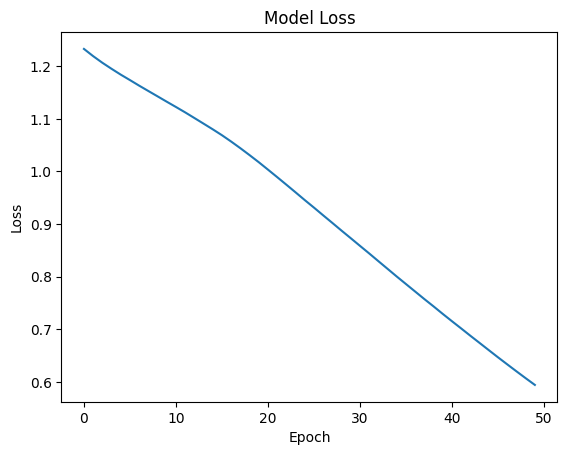

In [20]:
import matplotlib.pyplot as plt

plt.plot(hist.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
    